#### HUC12 maps of percent error

Creates HUC12 maps of percent error in public supply and irrigation water use predictions. 

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import tempfile
import imageio.v2 as imageio

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/HUC12_percent_error_maps")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- MANUAL SET UP ----------

# for each calibration scenario you want included in the figure, set scenario name, run date

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

In [3]:
##### ---------- IMPORT GEO BOUNDARIES ----------

GBSJ_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/GBSJ_HUC12.shp")
LCRR_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/LCRR_HUC12.shp")
MILK_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/MILK_HUC12.shp")

# get column in right format for merge 
GBSJ_huc12 = GBSJ_huc12.rename(columns={"huc12": "HUC12"})
LCRR_huc12 = LCRR_huc12.rename(columns={"huc12": "HUC12"})
MILK_huc12 = MILK_huc12.rename(columns={"huc12": "HUC12"})

GBSJ_huc12['HUC12'] = GBSJ_huc12['HUC12'].astype(int)
LCRR_huc12['HUC12'] = LCRR_huc12['HUC12'].astype(int)
MILK_huc12['HUC12'] = MILK_huc12['HUC12'].astype(int)

# prep CRS for maps
target_crs = GBSJ_huc12.crs

LCRR_huc12 = LCRR_huc12.to_crs(target_crs)
MILK_huc12 = MILK_huc12.to_crs(target_crs)

In [4]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]
        
        # get mean prediction across runs
        model_data_mean = (
            model_data
            .groupby(['Year', 'HUC12'])[
                [f'public_supply_mil_gal_{scenario}', f'irrigation_mil_gal_{scenario}']
            ]
            .mean()
            .reset_index()
        )

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data_mean, on=['Year', 'HUC12'], how='outer')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

In [9]:
##### ---------- COMPUTE PERCENT ERROR ----------
def compute_percent_error(df, scenarios, actual_suffix='validation'):
    """
    Computes percent error for public supply and irrigation water use,
    per HUC12 per Year, for each scenario in `scenarios`.

    Percent error = (predicted - actual) / actual * 100

    Special cases:
        actual == 0 and predicted == 0  -> percent error = 0
        actual == 0 and predicted != 0  -> percent error = -999 (flag value)
        actual is NaN or predicted is NaN -> percent error = NaN

    Adds one column per variable per scenario, e.g.:
        public_supply_mil_gal_pct_error_calibration
        irrigation_mil_gal_pct_error_calibration
    """
    df = df.copy()
    variables = ['public_supply_mil_gal', 'irrigation_mil_gal']

    for s in scenarios:
        scenario = s['scenario']
        for var in variables:
            actual_col = f'{var}_{actual_suffix}'
            pred_col = f'{var}_{scenario}'
            err_col = f'{var}_pct_error_{scenario}'

            if actual_col not in df.columns:
                print(f"[warn] missing actual column '{actual_col}', skipping {err_col}")
                continue
            if pred_col not in df.columns:
                print(f"[warn] missing predicted column '{pred_col}', skipping {err_col}")
                continue

            actual = df[actual_col]
            predicted = df[pred_col]

            # default: standard percent error calc
            pct_err = (predicted - actual) / actual * 100

            # masks
            missing = actual.isna() | predicted.isna()
            actual_zero = (actual == 0) & ~missing
            zero_zero = actual_zero & (predicted == 0)
            zero_nonzero = actual_zero & (predicted != 0)

            # apply special cases
            pct_err = pct_err.mask(zero_zero, 0)
            pct_err = pct_err.mask(zero_nonzero, -999)
            pct_err = pct_err.mask(missing, pd.NA)

            df[err_col] = pct_err

    return df

# apply to every watershed's dataframe
data_for_fig = {
    w: compute_percent_error(data_for_fig[w], scenarios)
    for w in watersheds
}

In [11]:
##### ---------- AVERAGE PERCENT ERROR BY PERIOD ----------
def compute_period_avg_error(df, scenarios, periods):
    variables = ['public_supply_mil_gal', 'irrigation_mil_gal']
    results = {}

    for period_name, (yr_start, yr_end) in periods.items():
        period_df = df[(df['Year'] >= yr_start) & (df['Year'] <= yr_end)].copy()

        agg = period_df[['HUC12']].drop_duplicates().reset_index(drop=True)

        for s in scenarios:
            scenario = s['scenario']
            for var in variables:
                err_col = f'{var}_pct_error_{scenario}'
                if err_col not in period_df.columns:
                    continue

                flagged = period_df[err_col] == -999
                valid = period_df[err_col].where(~flagged)  # NaN out flags for averaging

                avg = (
                    period_df.assign(**{err_col: valid})
                    .groupby('HUC12')[err_col]
                    .mean()
                    .rename(f'{err_col}_avg')
                )
                n_flagged = (
                    period_df.assign(_flag=flagged)
                    .groupby('HUC12')['_flag']
                    .sum()
                    .rename(f'{err_col}_n_flagged')
                )

                agg = agg.merge(avg, on='HUC12', how='left')
                agg = agg.merge(n_flagged, on='HUC12', how='left')

        results[period_name] = agg

    return results

# define periods
periods = {
    'calibration_period': (2000, 2015),
    'validation_period': (2016, 2020),
}

# apply to every watershed's dataframe
period_avg_error = {
    w: compute_period_avg_error(data_for_fig[w], scenarios, periods)
    for w in watersheds
}

/tmp/ipykernel_3598596/2572921585.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


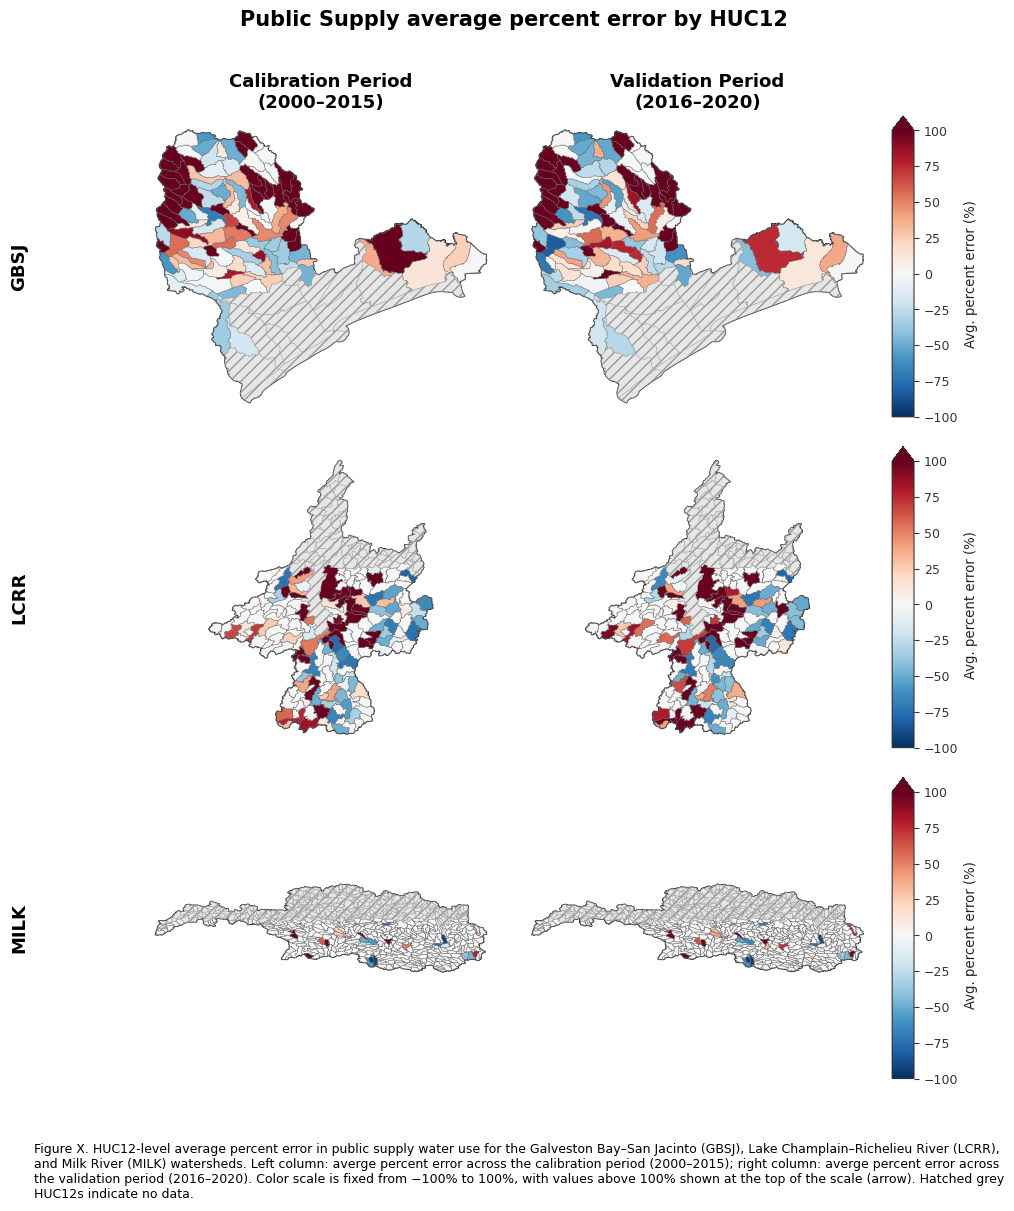

/tmp/ipykernel_3598596/2572921585.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


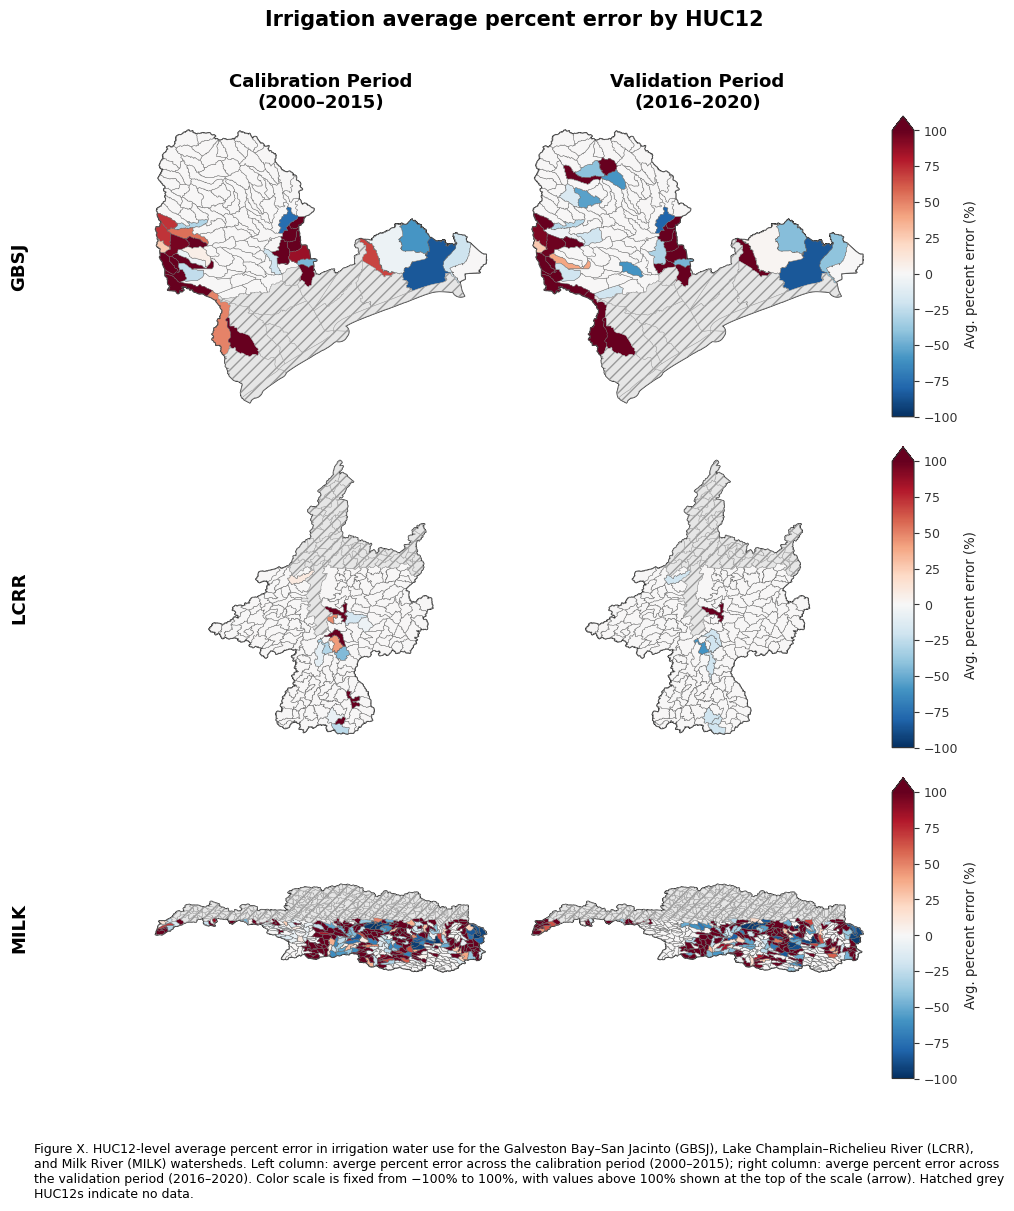

In [20]:
##### ---------- HUC12 CHOROPLETH MAPS: PERCENT ERROR, CALIBRATION vs. VALIDATION PERIOD ----------

##### ---------- MANUAL SET UP ----------

SCENARIO_TO_PLOT = scenarios[0]['scenario']
SCENARIO_LABEL = scenarios[0].get('label', SCENARIO_TO_PLOT.title())

geo_lookup = {
    'GBSJ': GBSJ_huc12,
    'LCRR': LCRR_huc12,
    'MILK': MILK_huc12,
}

water_use_types = [
    ('public_supply_mil_gal', 'Public Supply', 'RdBu_r'),
    ('irrigation_mil_gal', 'Irrigation', 'RdBu_r'),
]

PERIOD_PANELS = [
    ('calibration_period', 'Calibration Period\n(2000–2015)'),
    ('validation_period', 'Validation Period\n(2016–2020)'),
]

# fixed legend range for percent error
PCT_ERROR_VMIN = -100
PCT_ERROR_VMAX = 100

ALL_FLAGGED_COLOR = '#f5d800'  # yellow for HUC12s where every year was -999

##### ---------- STYLE ----------

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MISSING_KWDS = dict(color='#e6e6e6', edgecolor='#999999', linewidth=0.3, hatch='///', label='No data')
BOUNDARY_KWDS = dict(facecolor='none', edgecolor='#333333', linewidth=0.6)


##### ---------- BUILD ONE FIGURE PER WATER-USE TYPE ----------

for use_key, use_label, cmap_name in water_use_types:

    fig = plt.figure(figsize=(10, 12.5))
    gs = gridspec.GridSpec(
        nrows=3, ncols=3, width_ratios=[1, 1, 0.06],
        wspace=0.05, hspace=0.10, figure=fig
    )

    err_col = f'{use_key}_pct_error_{SCENARIO_TO_PLOT}_avg'
    flag_col = f'{use_key}_pct_error_{SCENARIO_TO_PLOT}_n_flagged'
    cmap = plt.get_cmap(cmap_name).copy()

    # fixed, zero-centered scale shared across all watersheds/panels
    norm = Normalize(vmin=PCT_ERROR_VMIN, vmax=PCT_ERROR_VMAX)

    row_first_axes = []

    for row, watershed in enumerate(watersheds):

        ax_cal = fig.add_subplot(gs[row, 0])
        ax_val = fig.add_subplot(gs[row, 1])
        cax = fig.add_subplot(gs[row, 2])
        row_first_axes.append(ax_cal)

        geo = geo_lookup[watershed]
        period_data = period_avg_error[watershed]  # dict: period_name -> DataFrame

        axes = [ax_cal, ax_val]

        for ax, (period_name, period_title) in zip(axes, PERIOD_PANELS):
            period_df = period_data[period_name]
            merged = geo.merge(period_df, on='HUC12', how='left')

            if err_col in merged.columns:
                # avg already excludes -999 years; NaN avg + flagged>0 means
                # every year in this period was a -999 case for that HUC12
                has_flags = merged[flag_col].fillna(0) > 0 if flag_col in merged.columns else pd.Series(False, index=merged.index)
                all_flagged = merged[err_col].isna() & has_flags

                # clip values into the fixed legend range for coloring
                # (raw avg value is preserved in err_col for reference/export)
                plot_col = f'__{use_key}_plot'
                merged[plot_col] = merged[err_col].clip(lower=PCT_ERROR_VMIN, upper=PCT_ERROR_VMAX)
                merged.loc[all_flagged, plot_col] = pd.NA  # keep out of normal colormap

                merged.plot(
                    column=plot_col, cmap=cmap, norm=norm,
                    linewidth=0.3, edgecolor='#666666',
                    missing_kwds=MISSING_KWDS,
                    ax=ax, zorder=2
                )

                # overlay solid yellow for HUC12s flagged -999 in every year
                flagged_geo = merged[all_flagged]
                if not flagged_geo.empty:
                    flagged_geo.plot(
                        color=ALL_FLAGGED_COLOR, edgecolor='#666666',
                        linewidth=0.3, ax=ax, zorder=3
                    )
            else:
                merged.plot(**MISSING_KWDS, ax=ax, zorder=2)

            # watershed outline on top
            geo.dissolve().boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=0)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_aspect('equal')

            if row == 0:
                ax.set_title(period_title, fontsize=13, fontweight='bold', pad=6)

        # ----- shared colorbar for this row, with overflow arrow for >100% -----
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, extend='max')
        cb.set_label('Avg. percent error (%)', fontsize=9.5)
        cb.ax.tick_params(labelsize=9)

    ##### ---------- SUPTITLE ----------
    fig.suptitle(
        f'{use_label} average percent error by HUC12',
        fontsize=15, fontweight='bold', y=0.965
    )

    ##### ---------- CAPTION ----------
    caption_text = (
        f"Figure X. HUC12-level average percent error in {use_label.lower()} water use for the Galveston Bay–San Jacinto (GBSJ), Lake Champlain–Richelieu River (LCRR),\n"
        f"and Milk River (MILK) watersheds. Left column: averge percent error across the calibration period (2000–2015); right column: averge percent error across\n" 
        f"the validation period (2016–2020). Color scale is fixed from −100% to 100%, with values above 100% shown at the top of the scale (arrow). Hatched grey\n" 
        f"HUC12s indicate no data."
    )
    fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)

    fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])

    ##### ---------- ALIGN WATERSHED ROW LABELS ----------
    for watershed, ax in zip(watersheds, row_first_axes):
        pos = ax.get_position()
        y_center = (pos.y0 + pos.y1) / 2
        fig.text(
            0.005, y_center, watershed,
            rotation=90, va='center', ha='center',
            fontsize=13, fontweight='bold'
        )

    save_path = out_dir / f"{use_key}_pct_error.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()